In [1]:
import os
import torch
import matplotlib.pyplot as plt


from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


class ResNetMoleClassifier(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ResNetMoleClassifier, self).__init__()

        self.resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)


def create_resnet_model(num_classes=4, pretrained=True):
    return ResNetMoleClassifier(num_classes, pretrained)

In [16]:
img_path = "../assets/ISIC_0011673.jpg"
img_path2 = "../assets/P_128_crop_0_dermal.jpg"

if os.path.exists(img_path):
    print(f"Image found at: {img_path}")
else:
    print(f"Image not found at: {img_path}")


Image found at: ../assets/ISIC_0011673.jpg


In [17]:
resnet_model = create_resnet_model(num_classes=4, pretrained=True).to(DEVICE)

OUR_CKPT = "../Experiment/resnet/SemanticMix+SSI/best_model.pth"

if os.path.exists(OUR_CKPT):
    print(f"Checkpoint found at: {OUR_CKPT}")
else:
    print(f"Checkpoint not found at: {OUR_CKPT}")

if os.path.isfile(OUR_CKPT):
    print("loading ckpt...")
    resnet_model.load_state_dict(torch.load(OUR_CKPT)['model_state_dict'])
    resnet_model.eval()
    print("load successfully...")

Checkpoint found at: ../Experiment/resnet/SemanticMix+SSI/best_model.pth
loading ckpt...
load successfully...


In [18]:
def run_grad_cam(model, target_layers, input_tensor, img_np, target_category=None, is_vit=False):

    model.eval()

    cam = GradCAM(model=model, target_layers=target_layers)

    targets = [ClassifierOutputTarget(target_category)] if target_category is not None else None

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    
    return visualization, grayscale_cam


def unnormalize(tensor):
    # 假设使用 ImageNet 标准均值方差
    mean = torch.tensor([0.485, 0.456, 0.406]).to(tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).to(tensor.device).view(3, 1, 1)
    img = tensor.clone() * std + mean
    img = img.clamp(0, 1)
    return img.squeeze(0).permute(1, 2, 0).cpu().numpy()


=== Prediction Results ===
Sample 1: Compound (95.76%)
Sample 2: Dermal (98.75%)


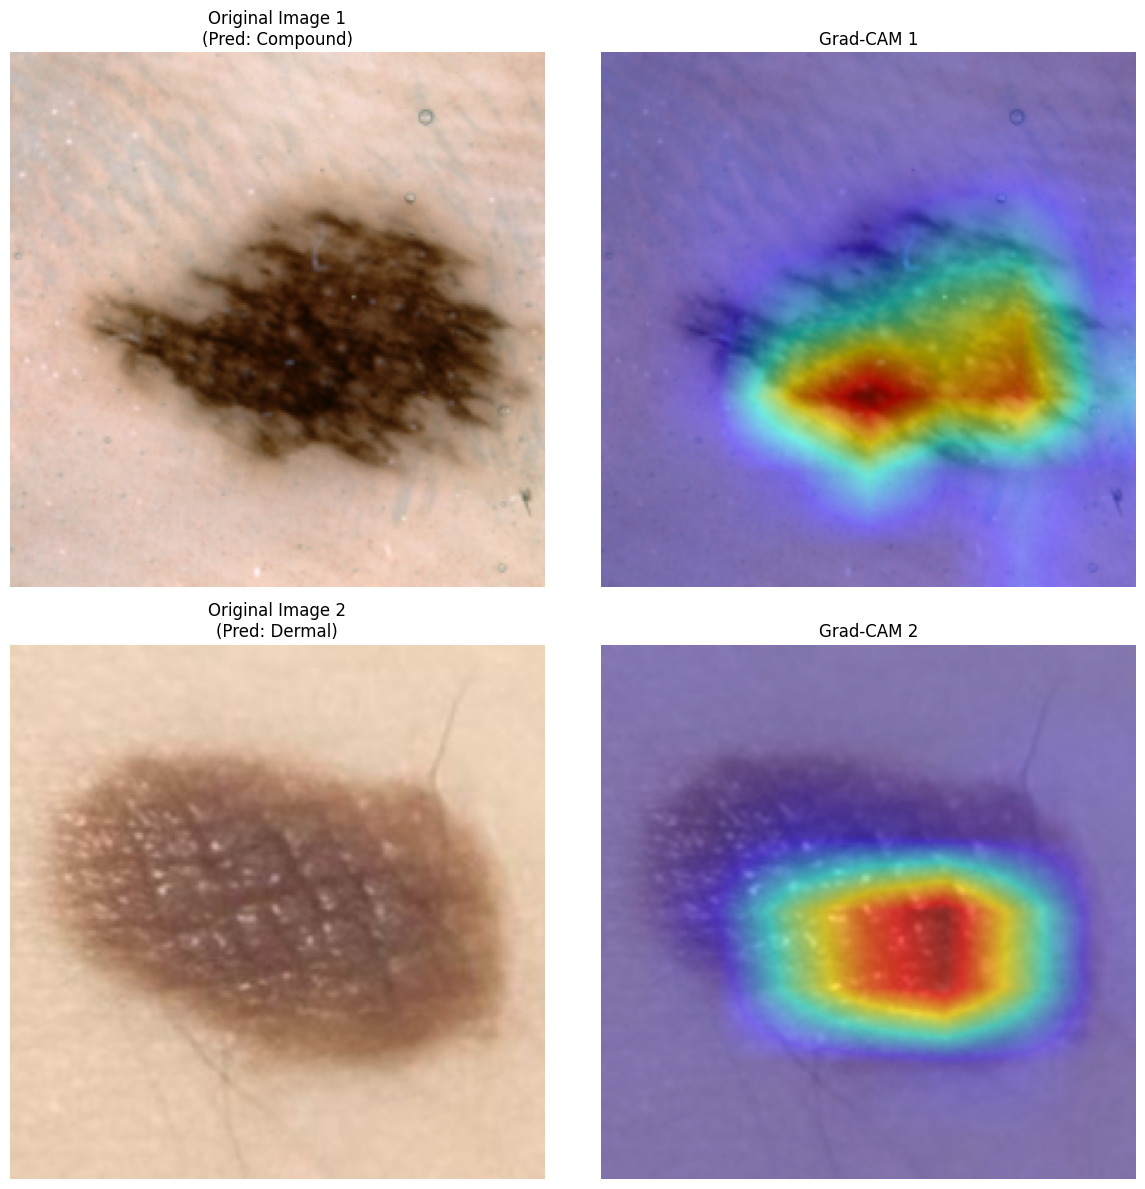

In [25]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def preprocess_image(img_path):
    image_pil = Image.open(img_path).convert('RGB')
    tensor = transform(image_pil)
    return tensor.unsqueeze(0).cuda()

image_tensor = preprocess_image(img_path)
image_tensor2 = preprocess_image(img_path2)

with torch.no_grad():
    outputs = resnet_model(image_tensor)
    outputs2 = resnet_model(image_tensor2)
    probabilities = torch.softmax(outputs, dim=1)
    probabilities2 = torch.softmax(outputs2, dim=1)
    predicted_class = torch.argmax(probabilities, dim=1).item()
    predicted_class2 = torch.argmax(probabilities2, dim=1).item()


target_layers = [resnet_model.resnet.layer4[-1]] 
with GradCAM(model=resnet_model, target_layers=target_layers) as cam:
    grayscale_cam = cam(input_tensor=image_tensor, 
                        targets=[ClassifierOutputTarget(predicted_class)])[0, :]
    grayscale_cam2 = cam(input_tensor=image_tensor2, 
                         targets=[ClassifierOutputTarget(predicted_class2)])[0, :]

raw_img = unnormalize(image_tensor)
raw_img2 = unnormalize(image_tensor2)
cam_image = show_cam_on_image(raw_img, grayscale_cam, use_rgb=True)
cam_image2 = show_cam_on_image(raw_img2, grayscale_cam2, use_rgb=True)

print(f"\n=== Prediction Results ===")
CLASS_NAMES = ["Compound", "Junctional", "Dermal", "Seborrheic"]
print(f"Sample 1: {CLASS_NAMES[predicted_class]} ({probabilities[0][predicted_class].item()*100:.2f}%)")
print(f"Sample 2: {CLASS_NAMES[predicted_class2]} ({probabilities2[0][predicted_class2].item()*100:.2f}%)")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
axes[0].imshow(raw_img)
axes[0].set_title(f"Original Image 1\n(Pred: {CLASS_NAMES[predicted_class]})")
axes[1].imshow(cam_image)
axes[1].set_title(f"Grad-CAM 1")

axes[2].imshow(raw_img2)
axes[2].set_title(f"Original Image 2\n(Pred: {CLASS_NAMES[predicted_class2]})")
axes[3].imshow(cam_image2)
axes[3].set_title(f"Grad-CAM 2")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()